#### A Deep Agent takes the create_agent you met yesterday and wraps it in an opinionated harness, the kind of setup you would otherwise build yourself for serious, multi-step work.

Three things come built in. A planning tool, so the agent can write itself a todo list and work through it. A filesystem, so it can save and reread its working notes rather than holding everything in the conversation. And sub-agents, so it can hand a focused piece of work to a helper with its own clean context. You supply the intent, and the harness supplies the structure.

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools import GoogleSerperRun
from langchain_community.utilities import GoogleSerperAPIWrapper
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

load_dotenv(override=True)

True

In [2]:
### web search tool
search = GoogleSerperRun(api_wrapper=GoogleSerperAPIWrapper())

In [4]:
### research agent that plans,searches and writes
sandbox = os.path.abspath("sandbox")
os.makedirs(sandbox,exist_ok = True)
model = ChatOpenAI(model = 'gpt-4o-mini')
researcher = create_deep_agent(
    model = model,
    tools = [search],
    system_prompt=(
        "You are a research analyst. Plan your work with your todo tool, "
        "research with the search tool, and write your findings as a tidy markdown briefing to a file."
    ),
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

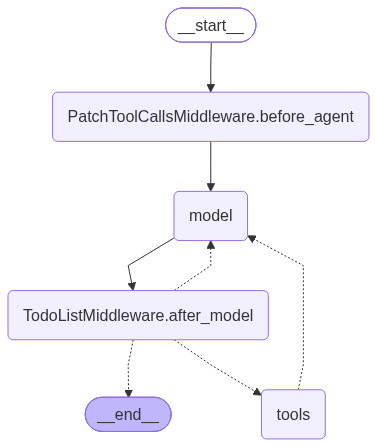

In [11]:
researcher

In [5]:
brief = """
Our company is planning to move its sales fleet to electric vehicles.
Research the public EV charging landscape in the US: find out roughly how many public charging points there are,
and pick out two major charging networks a fleet could rely on.
Write a one page markdown briefing, with a heading and a short section for each, to the file charging.md.
"""

result = researcher.invoke({"messages": [{"role": "user", "content": brief}]})
print(result["messages"][-1].content)

The markdown briefing has been created and saved to the file `charging.md`. It contains information about the public EV charging landscape in the US, including the number of charging points and details on two major charging networks. 

If you need any further modifications or additional information, let me know!


In [7]:
tools_used =[]
for message in result['messages']:
    tool_calls = getattr(message,"tool_calls",[])
    if tool_calls:
        for tool_call in tool_calls:
            tools_used.append(tool_call["name"])
print("Tools the agent called, in order:")
print(tools_used)

Tools the agent called, in order:
['google_serper', 'google_serper', 'write_file']


In [16]:
#check charging.md output

#### subagents

In [8]:
research_ev_instructions = """
You research one electric vehicle using the search tool and return three concise facts
that a fleet buyer would care about, such as price, range and charging.
"""

overall_instructions = """
You write comparison briefings for a company choosing electric vehicles for its sales fleet.
For each vehicle, delegate the research to your vehicle-researcher sub-agent,
then write a markdown comparison to a file, ending with a clear recommendation.
"""


research_subagent = {
    "name": "vehicle-researcher",
    "description": "Researches a single electric vehicle and returns a short list of facts about it.",
    "system_prompt": research_ev_instructions,
}

lead = create_deep_agent(
    model=model,
    tools=[search],
    system_prompt=overall_instructions,
    subagents=[research_subagent],
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

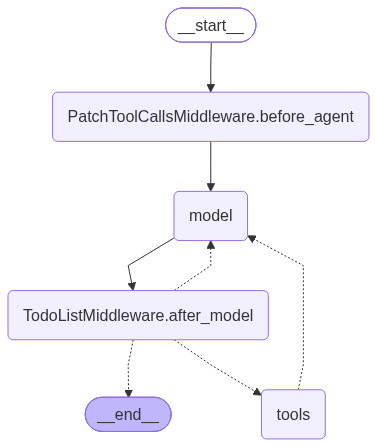

In [10]:
lead

In [13]:
mission = """
Compare the Tesla Model Y and the Ford Mustang Mach-E as candidates for our 100-car sales fleet.
Research each vehicle, then write a short markdown comparison with a recommendation to fleet.md.
"""

result = lead.invoke({"messages": [{"role": "user", "content": mission}]})

In [14]:
tools_used =[]
for message in result['messages']:
    tool_calls = getattr(message,"tool_calls",[])
    if tool_calls:
        for tool_call in tool_calls:
            tools_used.append(tool_call["name"])
print("Tools the agent called, in order:")
print(tools_used)

Tools the agent called, in order:
['task', 'task', 'write_file', 'read_file', 'edit_file', 'edit_file', 'edit_file']


In [15]:
## check fleet.md output

#### deepagents supports Anthropic's Agent Skills pattern, the same SKILL.md format that Claude Code uses.
A skill is just a folder containing a SKILL.md file: YAML frontmatter with a name and a description, followed by markdown instructions. Only the name and description go into the system prompt, and the agent reads the full file with its own read_file tool when it decides the skill is relevant. This is called progressive disclosure, and it means you can hand an agent a whole library of skills without flooding its context. Anthropic publishes a library of skills in this format at github.com/anthropics/skills, including the ones behind Claude's own document creation.

We have provided one in the sandbox: sandbox/skills/fleet-slide/SKILL.md, the house style of Voltway Research, our fictional analyst brand, for turning a recommendation into a single slide. Open it and have a read before we hand it to an agent.

### sub-agent that makes the slide
Now for the payoff. We define a slide-maker sub-agent and give it two things the lead agent does not have: the fleet-slide skill, and a create_slide tool of its own. The tool wraps a slide template in slide_kit.py that handles the design work, with brand colors, logo and layout all taken care of, so the sub-agent's job is to read the briefing, distill the message, and follow the house style. Sub-agents can carry their own tools, models and skills, which is how you build a team of specialists around one lead agent.

In [23]:
from langchain_core.tools import tool
from slide_kit import build_slide

@tool
def create_slide(title: str, key_points: list[str], recommendation: str) -> str:
    """Create a one-slide PowerPoint in the Voltway Research house style, saved as fleet.pptx."""
    build_slide(title, key_points, recommendation, os.path.join(sandbox, "fleet.pptx"))
    return "Saved the slide to /fleet.pptx"

slide_maker = {
    "name": "slide-maker",
    "description": "Turns a finished recommendation into a one-slide PowerPoint deck.",
    "system_prompt": "You turn research recommendations into slides, following your fleet-slide skill.",
    "tools": [create_slide],
    "skills": ["/skills/"],
}

presenter = create_deep_agent(
    model=model,
    subagents=[slide_maker],
    system_prompt="You prepare research for presentation by delegating to your slide-maker sub-agent.",
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

In [ ]:
result = presenter.invoke({"messages": [{"role": "user", "content":
    "Read fleet.md and have a one-slide deck made of its recommendation."}]})
print(result["messages"][-1].content)